In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


DATA_DIR = Path("../data/raw/realwaste-main/RealWaste")

In [2]:
records=[]
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue 

    for image_path in sorted(class_dir.iterdir()):
        if image_path.is_file():
            records.append({
                "Path":image_path ,
                "label":class_dir.name ,
            })

df=pd.DataFrame(records)

print(f"Total images: {len(df)}")
df.head()

Total images: 4752


,Path,label
0,../data/raw/realwaste-main/RealWaste/Cardboard...,Cardboard
1,../data/raw/realwaste-main/RealWaste/Cardboard...,Cardboard
2,../data/raw/realwaste-main/RealWaste/Cardboard...,Cardboard
3,../data/raw/realwaste-main/RealWaste/Cardboard...,Cardboard
4,../data/raw/realwaste-main/RealWaste/Cardboard...,Cardboard


label
Cardboard              461
Food Organics          411
Glass                  420
Metal                  790
Miscellaneous Trash    495
Paper                  500
Plastic                921
Textile Trash          318
Vegetation             436
Name: count, dtype: int64


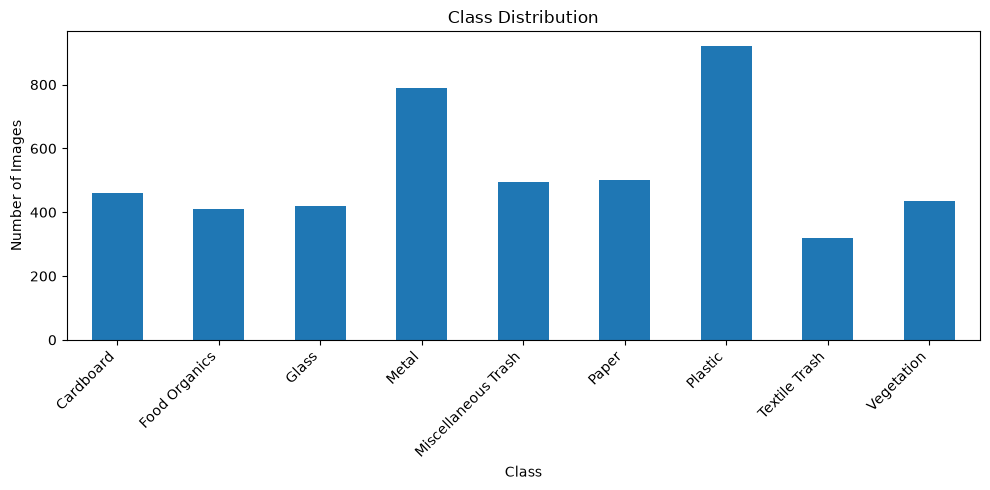

In [3]:
class_counts = df["label"].value_counts().sort_index()

print(class_counts)

class_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
properties = []

for path in df["Path"]:
    with Image.open(path) as img:
        properties.append({
            "width": img.width,
            "height": img.height,
            "mode": img.mode,
            "format": img.format,
        })

props_df = pd.DataFrame(properties)

print(props_df.describe(include="all"))
print("\nModes:")
print(props_df["mode"].value_counts())

print("\nFormats:")
print(props_df["format"].value_counts())

print("\nSizes:")
print(props_df[["width", "height"]].value_counts())

         width  height  mode format
count   4752.0  4752.0  4752   4752
unique     NaN     NaN     1      1
top        NaN     NaN   RGB   JPEG
freq       NaN     NaN  4752   4752
mean     524.0   524.0   NaN    NaN
std        0.0     0.0   NaN    NaN
min      524.0   524.0   NaN    NaN
25%      524.0   524.0   NaN    NaN
50%      524.0   524.0   NaN    NaN
75%      524.0   524.0   NaN    NaN
max      524.0   524.0   NaN    NaN

Modes:
mode
RGB    4752
Name: count, dtype: int64

Formats:
format
JPEG    4752
Name: count, dtype: int64

Sizes:
width  height
524    524       4752
Name: count, dtype: int64


In [8]:
import hashlib

def file_hash(path):
    return hashlib.md5(path.read_bytes()).hexdigest()

df["hash"] = df["Path"].apply(file_hash)

duplicate_groups = df[df["hash"].duplicated(keep=False)].sort_values("hash")

print(f"Duplicate images: {len(duplicate_groups)}")
print(f"Duplicate groups: {duplicate_groups['hash'].nunique()}")

Duplicate images: 0
Duplicate groups: 0


In [10]:
import torch

from waste_classifier.data.loaders import create_dataloaders
from waste_classifier.data.dataset import CLASS_NAMES
from waste_classifier.models.cnn import WasteCNN


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = Path("../models/best_model.pth")

In [11]:
confusion_pairs = [
    ("Plastic", "Metal"),
    ("Metal", "Plastic"),
    ("Metal", "Miscellaneous Trash"),
    ("Textile Trash", "Miscellaneous Trash"),
    ("Vegetation", "Miscellaneous Trash"),
]

_, _, test_loader = create_dataloaders(
    DATA_DIR,
    batch_size=32,
)

model = WasteCNN(num_classes=9).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

errors_by_pair = {pair: [] for pair in confusion_pairs}

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        predictions = outputs.argmax(dim=1).cpu()

        for image, true_idx, pred_idx in zip(images, labels, predictions):
            true_name = CLASS_NAMES[true_idx]
            pred_name = CLASS_NAMES[pred_idx]

            pair = (true_name, pred_name)

            if pair in errors_by_pair:
                errors_by_pair[pair].append(image)

for pair, images in errors_by_pair.items():
    print(f"{pair[0]} -> {pair[1]}: {len(images)}")

Plastic -> Metal: 26
Metal -> Plastic: 12
Metal -> Miscellaneous Trash: 9
Textile Trash -> Miscellaneous Trash: 9
Vegetation -> Miscellaneous Trash: 10


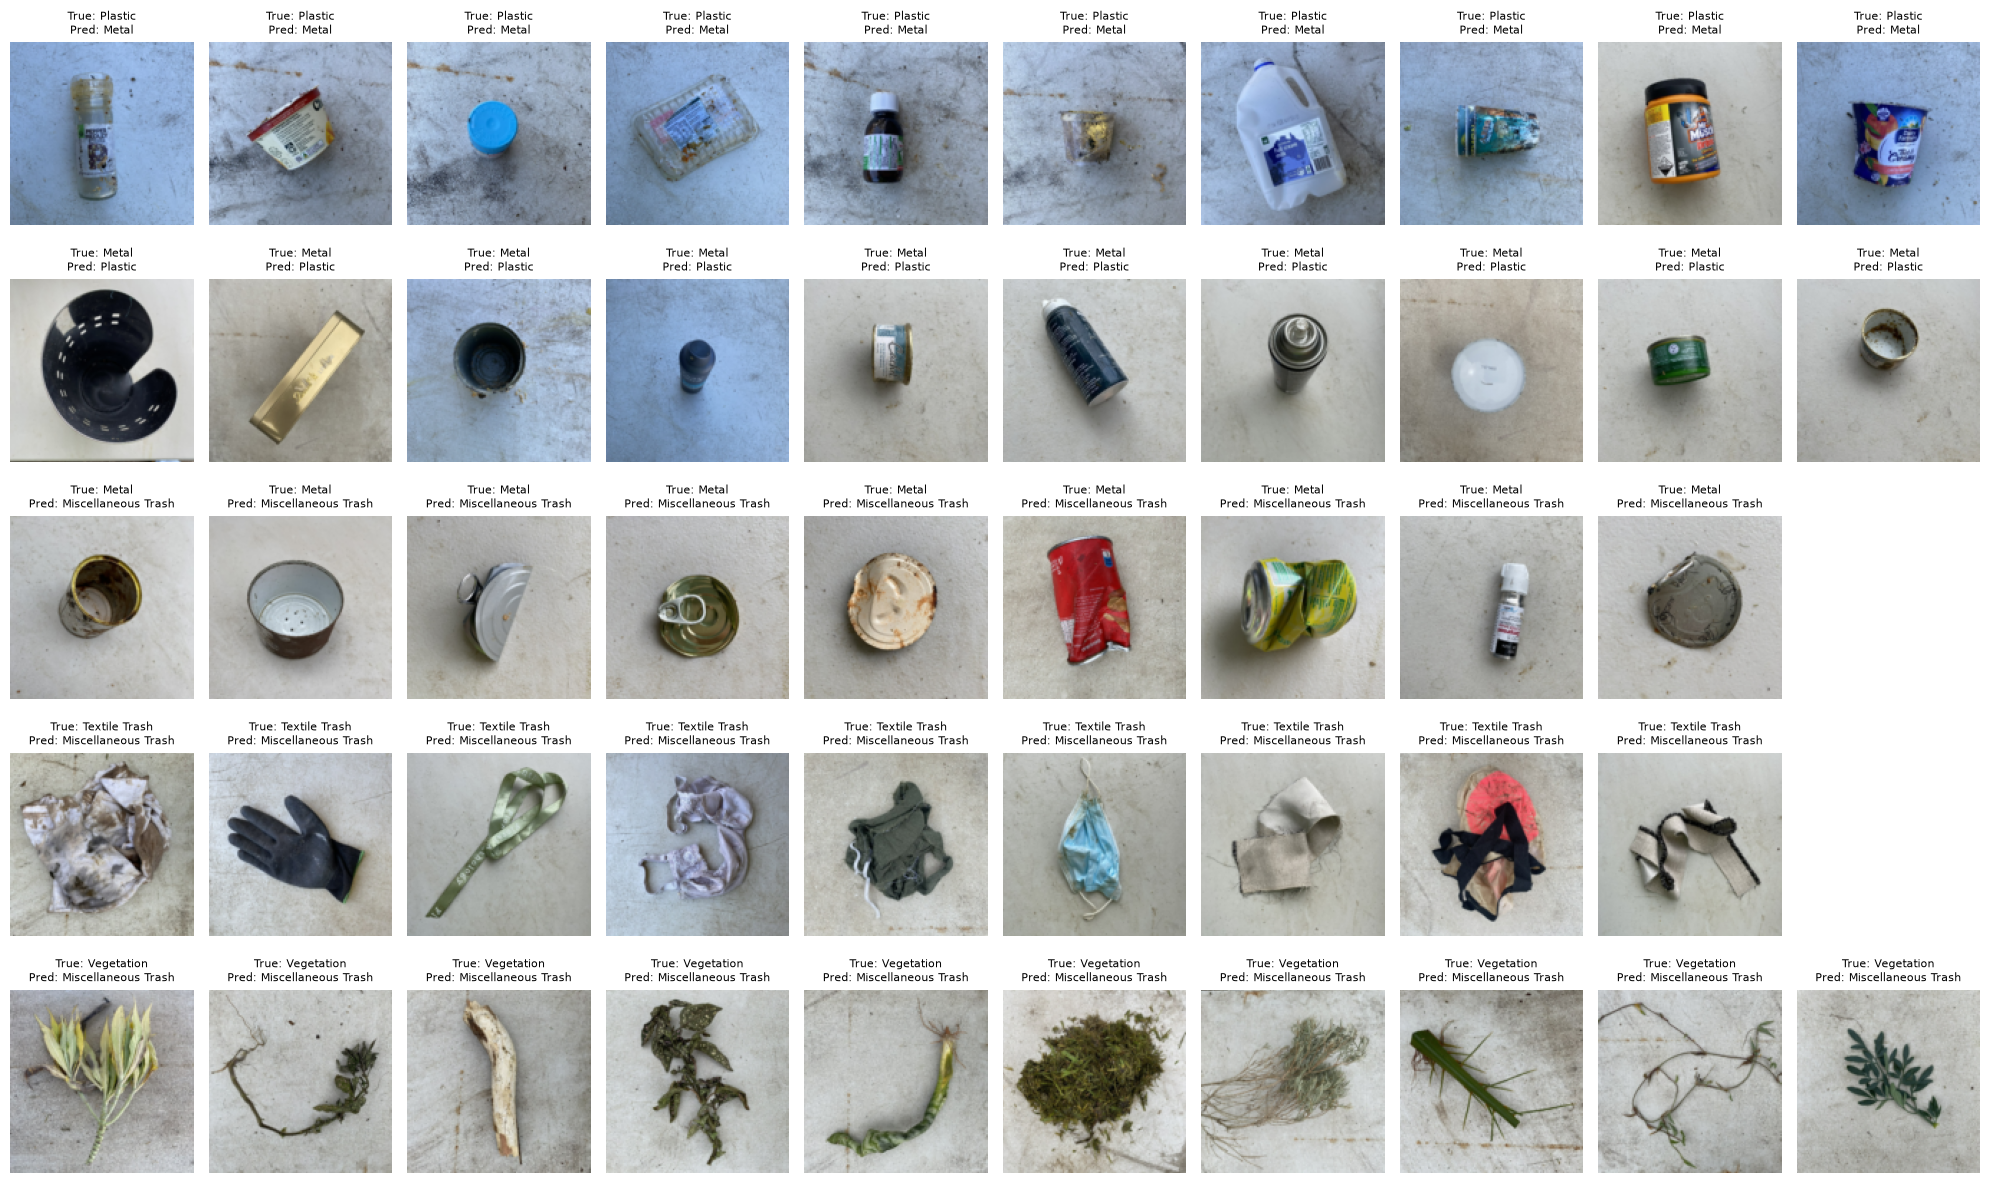

In [15]:
fig, axes = plt.subplots(
    5, 10,
    figsize=(20, 12)
)

for row, (pair, images) in enumerate(errors_by_pair.items()):
    for col in range(10):
        ax = axes[row, col]
        ax.axis("off")

        if col < len(images):
            image = images[col].permute(1, 2, 0)
            image = image * 0.5 + 0.5
            image = image.clamp(0, 1)

            ax.imshow(image)

            ax.set_title(
                f"True: {pair[0]}\nPred: {pair[1]}",
                fontsize=8
            )

plt.tight_layout()
plt.show()

In [17]:
from collections import Counter

from waste_classifier.data.split import (
    collect_images,
    stratified_split,
)

In [18]:
records = collect_images(DATA_DIR)

train_records, val_records, test_records = stratified_split(records)

for name, split in [
    ("Train", train_records),
    ("Validation", val_records),
    ("Test", test_records),
]:
    counts = Counter(record.label for record in split)

    print(f"\n{name}: {len(split)}")
    print(pd.Series(counts).sort_index())


Train: 3326
Cardboard              323
Food Organics          288
Glass                  294
Metal                  553
Miscellaneous Trash    346
Paper                  350
Plastic                645
Textile Trash          222
Vegetation             305
dtype: int64

Validation: 713
Cardboard               69
Food Organics           61
Glass                   63
Metal                  119
Miscellaneous Trash     74
Paper                   75
Plastic                138
Textile Trash           48
Vegetation              66
dtype: int64

Test: 713
Cardboard               69
Food Organics           62
Glass                   63
Metal                  118
Miscellaneous Trash     75
Paper                   75
Plastic                138
Textile Trash           48
Vegetation              65
dtype: int64
